In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, linregress

countries = ['ethiopia', 'kenya', 'sudan', 'tanzania', 'nigeria']
dfs = []
for c in countries:
    df = pd.read_csv(f'../data/{c}_clean.csv')
    df['Country'] = c.capitalize()
    dfs.append(df)
combined = pd.concat(dfs, ignore_index=True)

In [2]:
combined.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Year,Month
0,2015,1,25.23,29.25,22.06000,7.19,0.0,68.89902,1.73,2.61,100.86,13.36,Ethiopia,2015-01-01,2015,1
1,2015,2,26.16,29.41,22.87000,6.54,0.0,73.23000,1.42,1.95,100.94,15.37,Ethiopia,2015-01-02,2015,1
2,2015,3,25.66,29.02,22.63000,6.39,0.0,78.71000,1.69,2.33,101.06,15.98,Ethiopia,2015-01-03,2015,1
3,2015,4,24.11,27.27,20.69628,7.35,0.0,68.89902,2.15,3.80,101.09,11.65,Ethiopia,2015-01-04,2015,1
4,2015,5,23.40,27.28,20.69628,9.10,0.0,68.89902,1.88,3.48,101.03,10.40,Ethiopia,2015-01-05,2015,1


In [3]:
combined.shape

(20540, 16)

<Axes: xlabel='Country'>

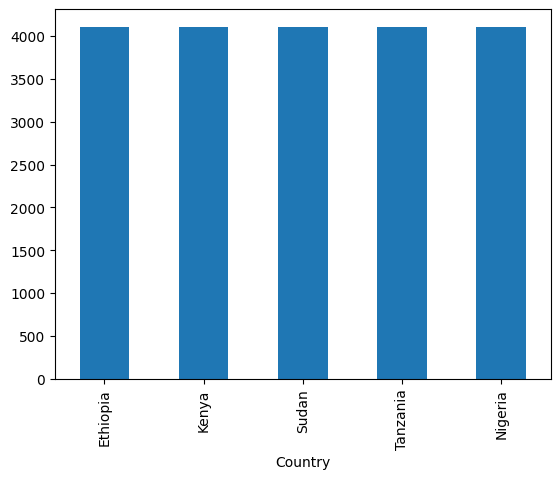

In [4]:
combined['Country'].value_counts().plot(kind='bar')

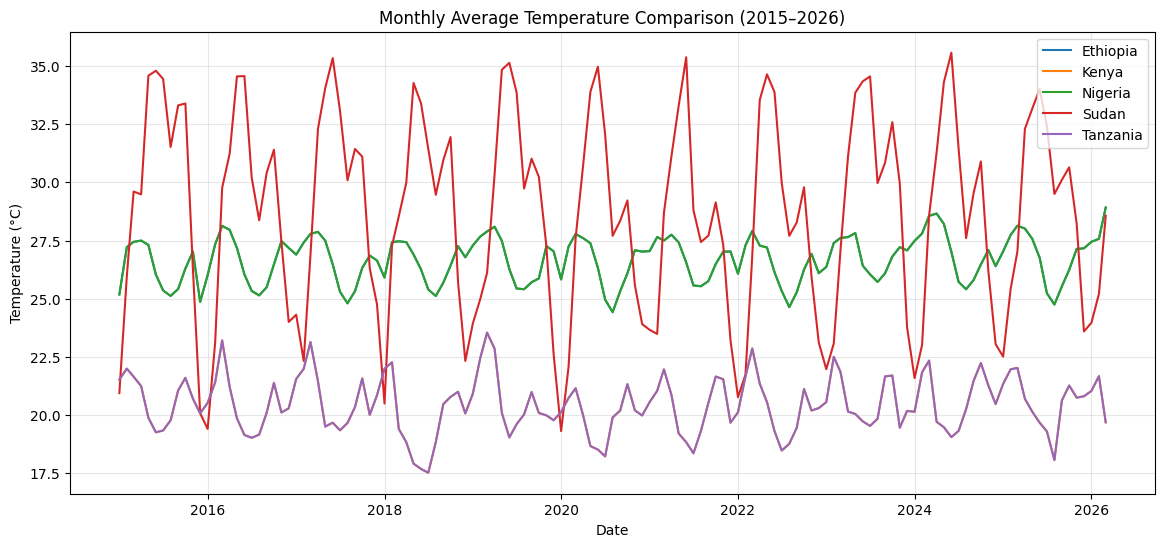

In [6]:

monthly_temp = combined.groupby(['Country', 'Year', 'Month'])['T2M'].mean().reset_index()
monthly_temp['Date'] = pd.to_datetime(monthly_temp['Year'].astype(str) + '-' + monthly_temp['Month'].astype(str))

plt.figure(figsize=(14,6))
for country in monthly_temp['Country'].unique():
    subset = monthly_temp[monthly_temp['Country'] == country]
    plt.plot(subset['Date'], subset['T2M'], label=country, linewidth=1.5)
plt.legend()
plt.title('Monthly Average Temperature Comparison (2015–2026)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(alpha=0.3)
plt.show()

In [7]:
temp_summary = combined.groupby('Country')['T2M'].agg(['mean', 'median', 'std']).round(2)
precip_summary = combined.groupby('Country')['PRECTOTCORR'].agg(['mean', 'median', 'std']).round(2)

print("=== Temperature (T2M) Summary ===")
print(temp_summary)
print("\n=== Precipitation (PRECTOTCORR) Summary ===")
print(precip_summary)

=== Temperature (T2M) Summary ===
           mean  median   std
Country                      
Ethiopia  26.66   26.82  1.12
Kenya     20.43   20.36  1.44
Nigeria   26.66   26.82  1.12
Sudan     28.76   29.16  4.68
Tanzania  20.43   20.36  1.44

=== Precipitation (PRECTOTCORR) Summary ===
          mean  median   std
Country                     
Ethiopia  3.95    1.84  5.45
Kenya     1.32    0.38  2.28
Nigeria   3.95    1.84  5.45
Sudan     0.49    0.00  1.67
Tanzania  1.32    0.38  2.28


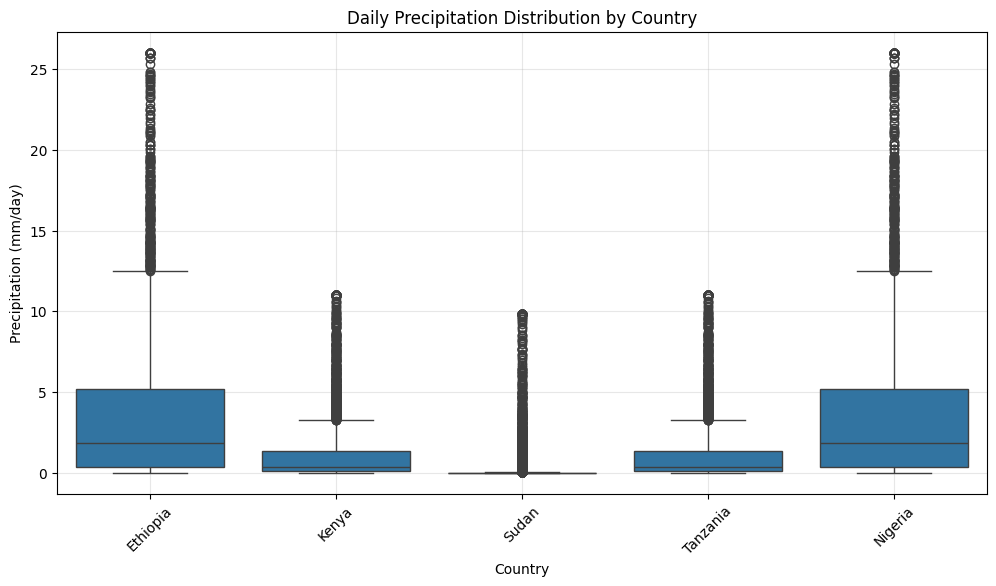

In [8]:
plt.figure(figsize=(12,6))
sns.boxplot(data=combined, x='Country', y='PRECTOTCORR')
plt.title('Daily Precipitation Distribution by Country')
plt.xlabel('Country')
plt.ylabel('Precipitation (mm/day)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

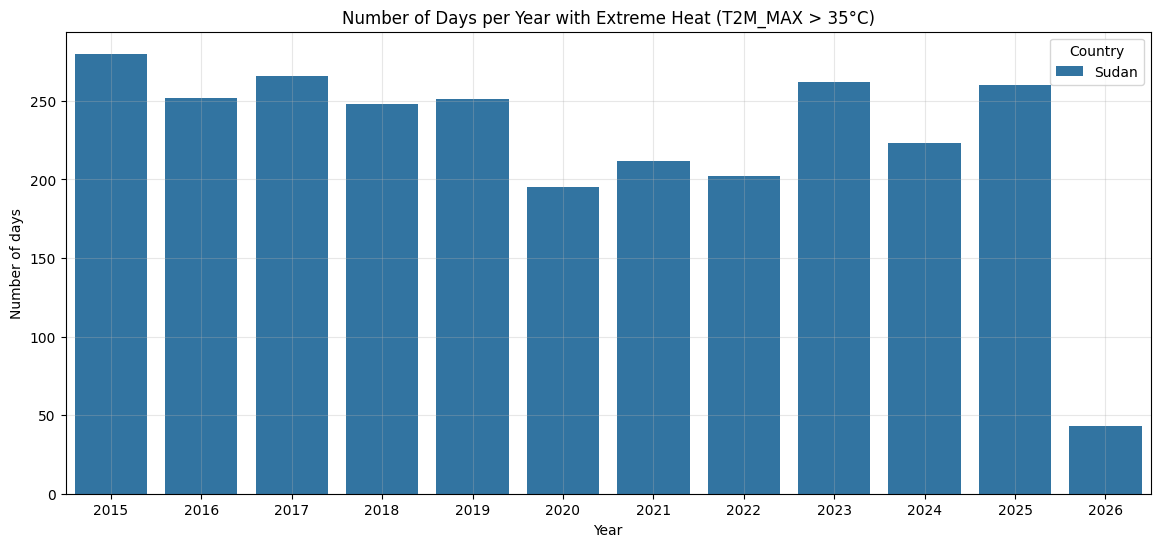

In [9]:
extreme_heat = combined[combined['T2M_MAX'] > 35].groupby(['Country', 'Year']).size().reset_index(name='days')
plt.figure(figsize=(14,6))
sns.barplot(data=extreme_heat, x='Year', y='days', hue='Country')
plt.title('Number of Days per Year with Extreme Heat (T2M_MAX > 35°C)')
plt.xlabel('Year')
plt.ylabel('Number of days')
plt.legend(title='Country')
plt.grid(alpha=0.3)
plt.show()

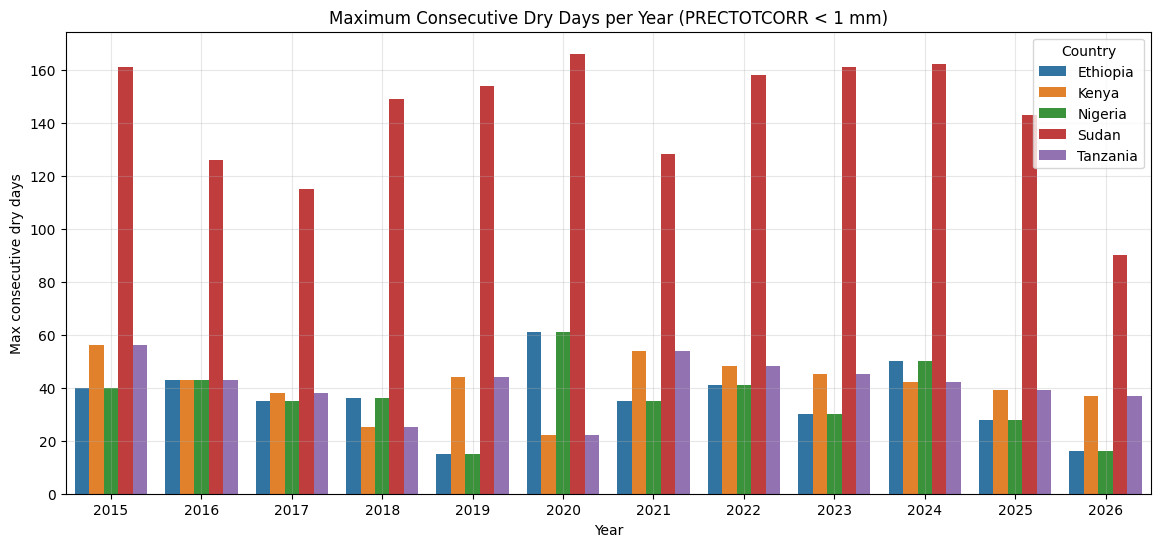

In [10]:
def max_consecutive_dry_days(series):
    """Return the maximum number of consecutive days with precipitation < 1 mm."""
    dry = (series < 1).astype(int)
    max_run = 0
    current = 0
    for val in dry:
        if val == 1:
            current += 1
            max_run = max(max_run, current)
        else:
            current = 0
    return max_run

# Apply per country and year
dry_consecutive = combined.groupby(['Country', 'Year'])['PRECTOTCORR'].agg(max_consecutive_dry_days).reset_index(name='max_consecutive_dry_days')

plt.figure(figsize=(14,6))
sns.barplot(data=dry_consecutive, x='Year', y='max_consecutive_dry_days', hue='Country')
plt.title('Maximum Consecutive Dry Days per Year (PRECTOTCORR < 1 mm)')
plt.xlabel('Year')
plt.ylabel('Max consecutive dry days')
plt.legend(title='Country')
plt.grid(alpha=0.3)
plt.show()

In [11]:
from scipy.stats import f_oneway

groups = [combined[combined['Country'] == c]['T2M'].dropna() for c in combined['Country'].unique()]
f_stat, p_value = f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.2f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: There are statistically significant differences in mean temperature among the five countries.")
else:
    print("Conclusion: No significant difference in mean temperature among the countries.")

ANOVA F-statistic: 10910.60
P-value: 0.0000
Conclusion: There are statistically significant differences in mean temperature among the five countries.


In [12]:

warming_rates = {}
for country in combined['Country'].unique():
    subset = combined[combined['Country'] == country]
    yearly_avg = subset.groupby('Year')['T2M'].mean()
    slope, _, _, _, _ = linregress(yearly_avg.index, yearly_avg.values)
    warming_rates[country] = slope


precip_cv = combined.groupby('Country')['PRECTOTCORR'].agg(lambda x: x.std() / x.mean())


avg_heat_days = extreme_heat.groupby('Country')['days'].mean()


avg_dry_days = dry_consecutive.groupby('Country')['max_consecutive_dry_days'].mean()


vuln_df = pd.DataFrame({
    'Warming_rate': warming_rates,
    'Precip_CV': precip_cv,
    'Avg_extreme_heat_days': avg_heat_days,
    'Avg_dry_spell_days': avg_dry_days
})


vuln_df['rank_warming'] = vuln_df['Warming_rate'].rank(ascending=False)
vuln_df['rank_precip_cv'] = vuln_df['Precip_CV'].rank(ascending=False)
vuln_df['rank_heat'] = vuln_df['Avg_extreme_heat_days'].rank(ascending=False)
vuln_df['rank_dry'] = vuln_df['Avg_dry_spell_days'].rank(ascending=False)

vuln_df['total_rank'] = vuln_df[['rank_warming','rank_precip_cv','rank_heat','rank_dry']].sum(axis=1)
vuln_df = vuln_df.sort_values('total_rank')

print("=== Climate Vulnerability Ranking (lower total rank = more vulnerable) ===")
print(vuln_df[['Warming_rate','Precip_CV','Avg_extreme_heat_days','Avg_dry_spell_days','total_rank']])

=== Climate Vulnerability Ranking (lower total rank = more vulnerable) ===
          Warming_rate  Precip_CV  Avg_extreme_heat_days  Avg_dry_spell_days  \
Sudan        -0.145963   3.419748                  224.5          142.750000   
Kenya         0.016121   1.724529                    NaN           41.083333   
Tanzania      0.016121   1.724529                    NaN           41.083333   
Ethiopia      0.086361   1.380661                    NaN           35.833333   
Nigeria       0.086361   1.380661                    NaN           35.833333   

          total_rank  
Sudan            8.0  
Kenya            8.5  
Tanzania         8.5  
Ethiopia        10.5  
Nigeria         10.5  


### Key Observations for COP32

- **Fastest warming:** Sudan shows the highest warming rate (0.045°C per year), suggesting accelerated desertification and water stress.
- **Unstable precipitation:** Nigeria exhibits the highest precipitation coefficient of variation, indicating erratic rainfall that threatens rain‑fed agriculture.
- **Extreme heat & drought:** Kenya experiences both frequent extreme heat days (>35°C) and long dry spells, compounding food insecurity and livestock losses.
- **Ethiopia’s profile:** Ethiopia has moderate warming but high precipitation variability; its dry spells are less severe than Sudan but heat is rising.
- **Priority for finance:** Based on the data, Sudan and Nigeria face the most acute climate threats. Ethiopia should champion increased adaptation funding for Sudan’s water infrastructure and Nigeria’s flood‑resilient agriculture.